In [6]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt

# Set your project root
PROJECT_ROOT = Path(r"G:\Mon Drive\TIBO3A\MarketMakingProject")
os.chdir(PROJECT_ROOT)

print("Current directory:", Path.cwd())

from src.config import StrategyConfig
from src.data_loader import prepare_lob_data
from src.features import compute_features_v1
from src.calibration import calibrate_strategy_parameters, update_config_from_calibration
from src.strategy import AvellanedaMarketMaker
from src.backtester import Backtester
from src.pnl import compute_pnl_decomposition
from src.metrics import compute_performance_summary

Current directory: G:\Mon Drive\TIBO3A\MarketMakingProject


In [8]:
data_path = "data/raw/Largebookticker.csv"

df = prepare_lob_data(
    path=data_path
)

df_features = compute_features_v1(
    df=df,
    vol_window=100,
)

print(df_features.shape)
df_features.head()

(20000, 17)


,timestamp,symbol,best_bid_price,best_bid_qty,best_ask_price,best_ask_qty,mid_price,spread,volume,relative_spread,spread_bps,imbalance,bid_depth,ask_depth,total_depth,log_mid_return,rolling_volatility
0,2026-04-28 21:34:52.132676+00:00,BTCUSDT,76327.67,1.78717,76327.68,2.17814,76327.675,0.01,3.96531,1.310141e-07,0.00131,-0.098598,1.78717,2.17814,3.96531,0.0,0.0
1,2026-04-28 21:34:53.420398+00:00,BTCUSDT,76327.67,1.78717,76327.68,2.17789,76327.675,0.01,3.96506,1.310141e-07,0.00131,-0.098541,1.78717,2.17789,3.96506,0.0,0.0
2,2026-04-28 21:34:54.700675+00:00,BTCUSDT,76327.67,1.78635,76327.68,2.17049,76327.675,0.01,3.95684,1.310141e-07,0.00131,-0.097083,1.78635,2.17049,3.95684,0.0,0.0
3,2026-04-28 21:34:55.976833+00:00,BTCUSDT,76327.67,1.78635,76327.68,2.17241,76327.675,0.01,3.95876,1.310141e-07,0.00131,-0.097520,1.78635,2.17241,3.95876,0.0,0.0
4,2026-04-28 21:34:57.280770+00:00,BTCUSDT,76327.67,1.78920,76327.68,2.09017,76327.675,0.01,3.87937,1.310141e-07,0.00131,-0.077582,1.78920,2.09017,3.87937,0.0,0.0


In [9]:
df_features["spread_bps"].describe()

count    20000.000000
mean         0.001443
std          0.012070
min          0.001291
25%          0.001306
50%          0.001309
75%          0.001310
max          1.428561
Name: spread_bps, dtype: float64

In [10]:
def split_calibration_backtest_data(df, calibration_fraction=0.3):
    split_index = int(len(df) * calibration_fraction)
    calibration_data = df.iloc[:split_index].copy()
    backtest_data = df.iloc[split_index:].copy()
    return calibration_data, backtest_data


calibration_data, backtest_data = split_calibration_backtest_data(
    df_features,
    calibration_fraction=0.3,
)

print("Calibration rows:", len(calibration_data))
print("Backtest rows:", len(backtest_data))

Calibration rows: 6000
Backtest rows: 14000


In [11]:
base_config = StrategyConfig(
    symbol="BTCUSDT",
    tick_size=0.01,
    fee_rate=0.0,
    fill_horizon=5,
)

calibration = calibrate_strategy_parameters(
    df=calibration_data,
    config=base_config,
    tick_distances=range(1, 11),
    horizons=[1, 3, 5, 10],
)

# Important: relax spread filter for this showcase
calibration["min_spread_bps"] = 0.0

calibration_summary = {
    "p0": calibration["p0"],
    "k_fill": calibration["k_fill"],
    "kappa": calibration["kappa"],
    "max_volatility": calibration["max_volatility"],
    "min_depth": calibration["min_depth"],
    "min_spread_bps": calibration["min_spread_bps"],
    "fit_ok": calibration["fit_ok"],
}

calibration_summary

{'p0': 0.17449476714873352,
 'k_fill': 0.0018129567678014631,
 'kappa': 0.1812956767801463,
 'max_volatility': 4.43155789114882e-05,
 'min_depth': 2.617467,
 'min_spread_bps': 0.0,
 'fit_ok': True}

In [12]:
fill_table = calibration["fill_table"]
fill_table.head(20)

,horizon,distance_ticks,p_fill_bid,p_fill_ask,p_fill_mean
0,1,1,0.048000,0.050167,0.049083
1,1,2,0.047333,0.049333,0.048333
2,1,3,0.047333,0.049167,0.048250
3,1,4,0.047333,0.049000,0.048167
4,1,5,0.047167,0.049000,0.048083
5,1,6,0.047167,0.049000,0.048083
6,1,7,0.046833,0.049000,0.047917
7,1,8,0.046833,0.049000,0.047917
8,1,9,0.046833,0.049000,0.047917
9,1,10,0.046833,0.049000,0.047917


In [13]:
output_dir = Path("outputs/showcase")
output_dir.mkdir(parents=True, exist_ok=True)

fill_table.to_csv(output_dir / "fill_table.csv", index=False)

In [14]:
def fee_to_label(fee_rate):
    return f"fee_{fee_rate:.5f}".replace(".", "p")


def run_one_backtest(fee_rate, backtest_data, calibration):
    config = StrategyConfig(
        symbol="BTCUSDT",
        tick_size=0.01,
        fee_rate=fee_rate,
        fill_horizon=5,
    )

    config = update_config_from_calibration(
        config=config,
        calibration=calibration,
    )

    strategy = AvellanedaMarketMaker(config=config)

    backtester = Backtester(
        data=backtest_data,
        strategy=strategy,
    )

    results = backtester.run(show_progress=False)
    trades = backtester.get_trades()

    pnl_decomp = compute_pnl_decomposition(
        results=results,
        trades=trades,
        market_data=backtest_data,
        adverse_selection_horizon=config.fill_horizon,
    )

    summary = compute_performance_summary(
        results=results,
        trades=trades,
        pnl_decomposition=pnl_decomp,
    )

    summary["fee_rate"] = fee_rate
    summary["fee_label"] = fee_to_label(fee_rate)

    return results, trades, summary, pnl_decomp


def save_pnl_plot(results, fee_rate, output_dir):
    fee_label = fee_to_label(fee_rate)

    plt.figure(figsize=(10, 5))
    plt.plot(results["pnl"])
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Backtest step")
    plt.ylabel("PnL")
    plt.title(f"PnL Curve - fee_rate={fee_rate}")
    plt.grid(True)
    plt.tight_layout()

    path = output_dir / f"pnl_curve_{fee_label}.png"
    plt.savefig(path, dpi=300)
    plt.show()

    return path


def save_inventory_plot(results, fee_rate, output_dir):
    fee_label = fee_to_label(fee_rate)

    plt.figure(figsize=(10, 5))
    plt.plot(results["inventory"])
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Backtest step")
    plt.ylabel("Inventory")
    plt.title(f"Inventory Curve - fee_rate={fee_rate}")
    plt.grid(True)
    plt.tight_layout()

    path = output_dir / f"inventory_curve_{fee_label}.png"
    plt.savefig(path, dpi=300)
    plt.show()

    return path

Running fee_rate = 0.0


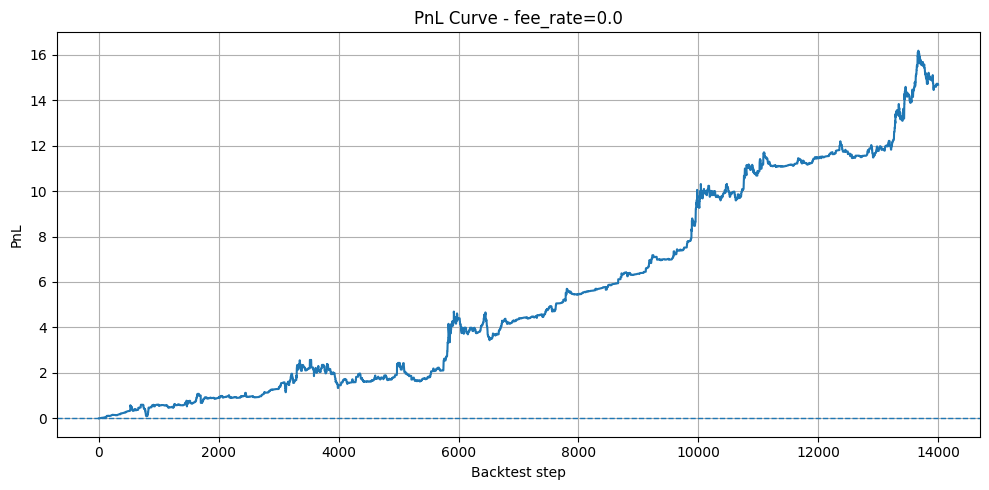

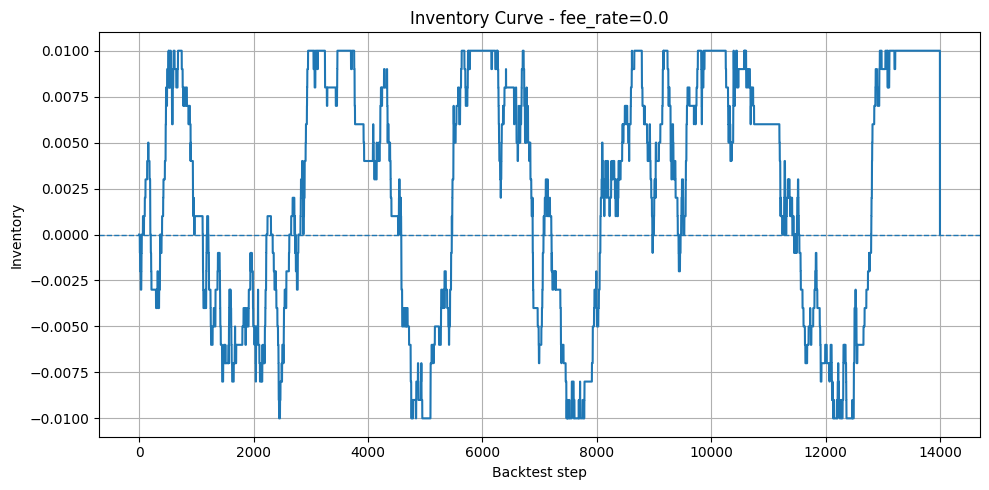

Final PnL: 14.680110000000127
Trades: 955
Fees: 0.0
Running fee_rate = 1e-05


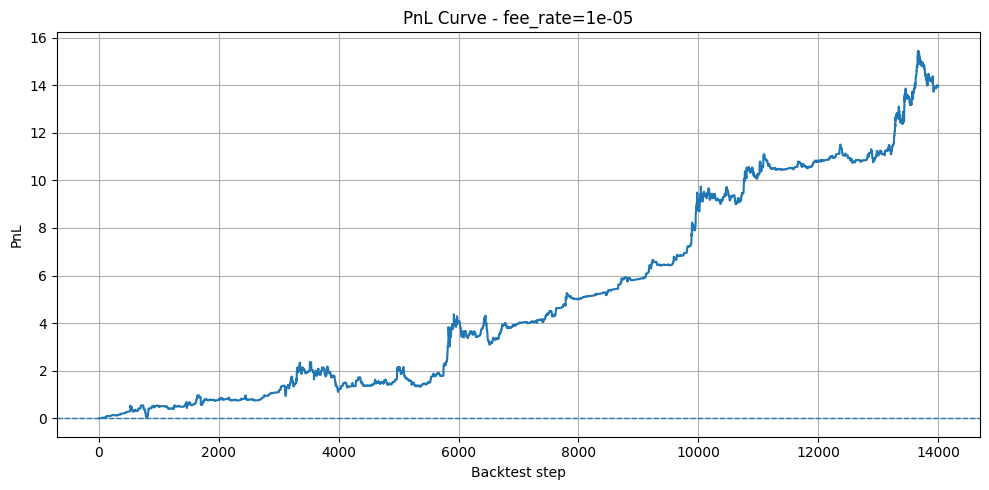

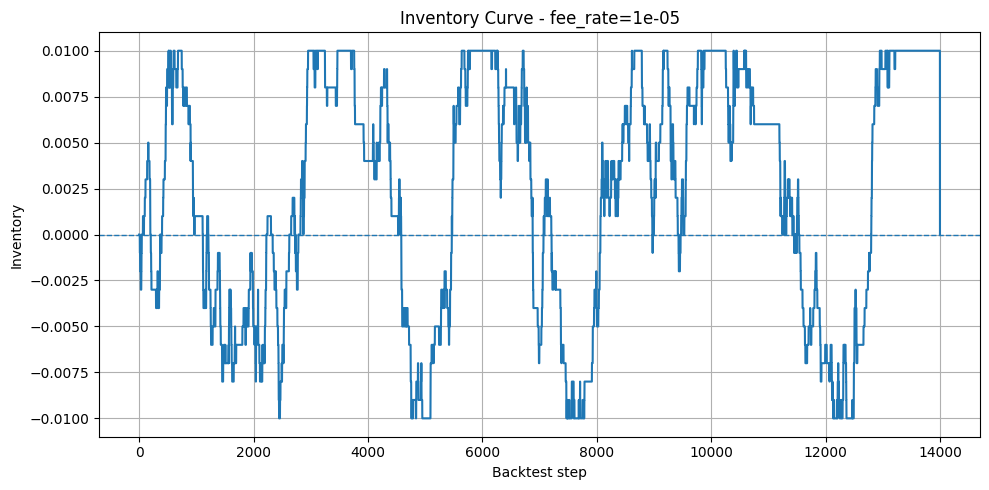

Final PnL: 13.942261495300688
Trades: 955
Fees: 0.7378485047000001
Running fee_rate = 5e-05


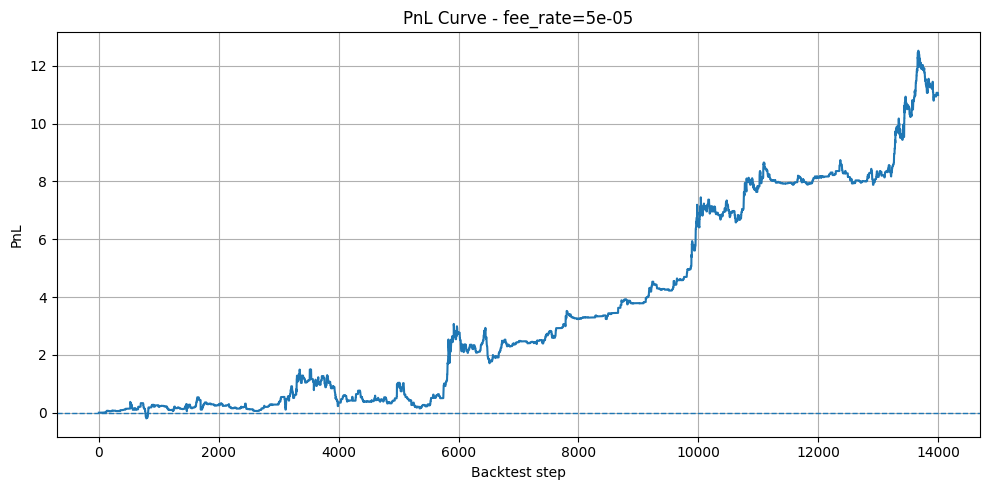

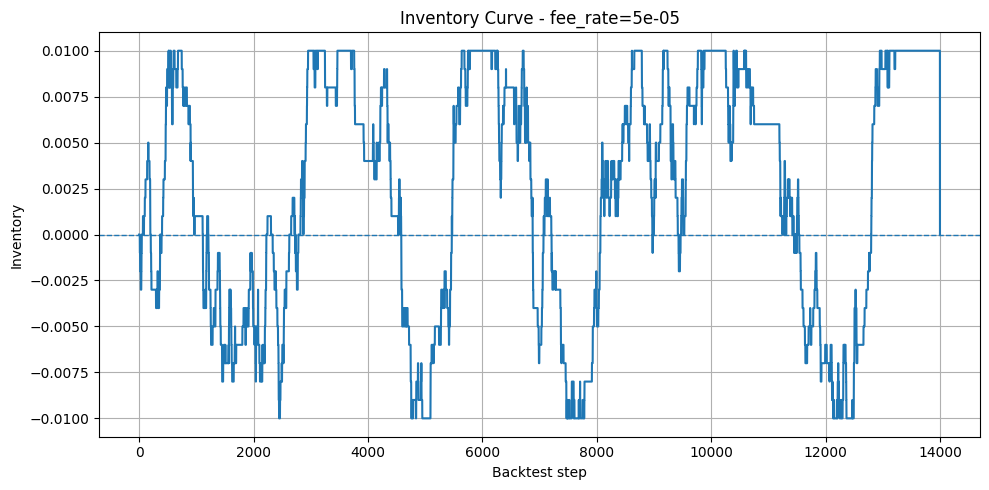

Final PnL: 10.990867476502592
Trades: 955
Fees: 3.6892425235000004
Running fee_rate = 0.0001


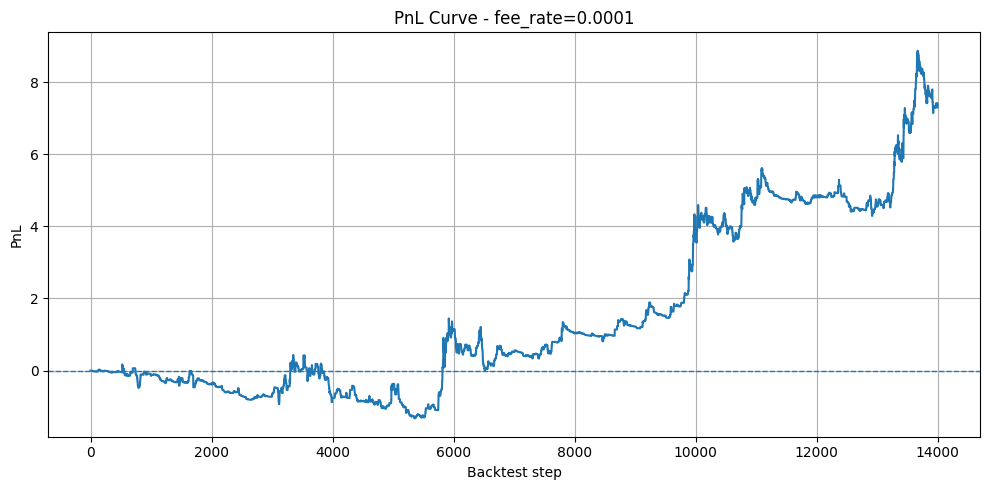

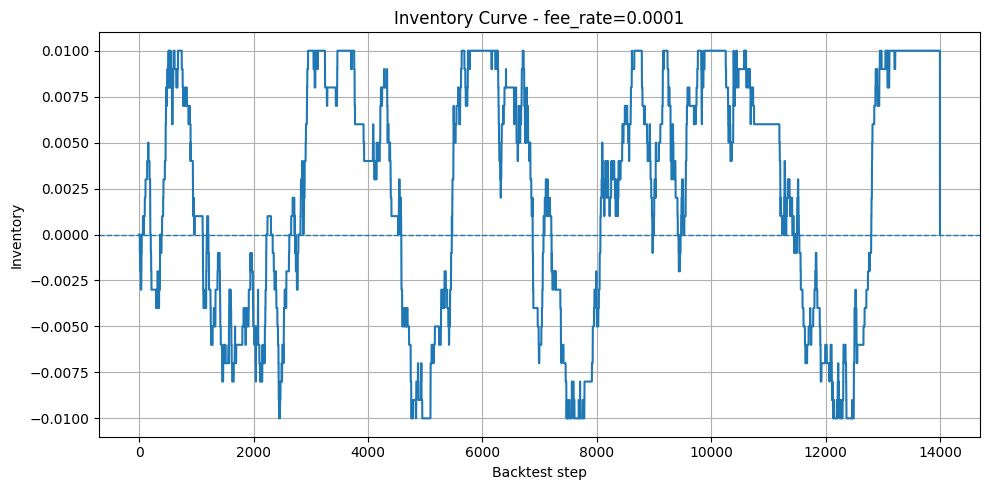

Final PnL: 7.3016249530007356
Trades: 955
Fees: 7.378485047000001
Running fee_rate = 0.0002


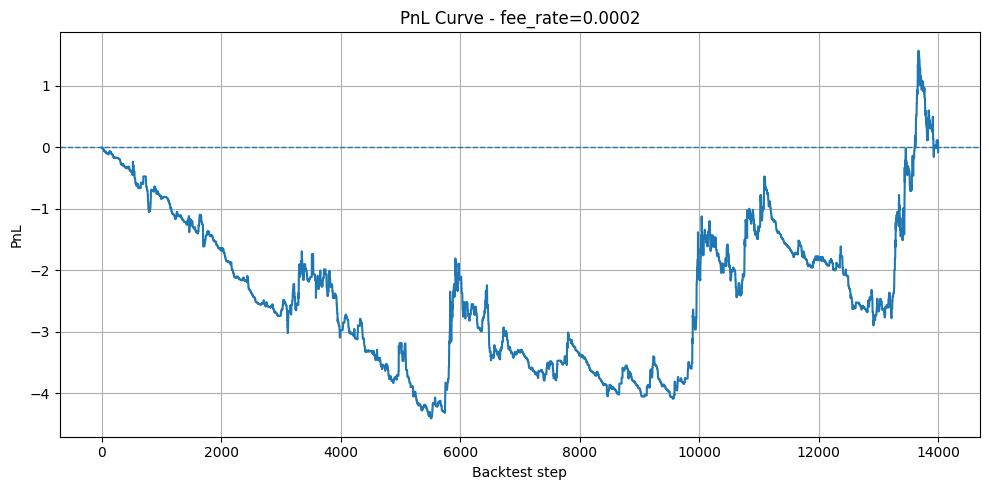

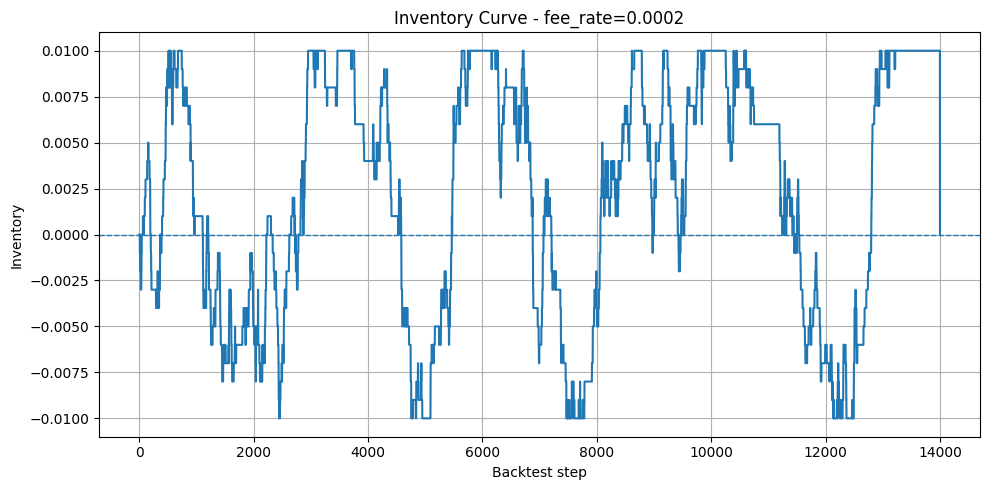

Final PnL: -0.07686009400127117
Trades: 955
Fees: 14.756970094000001


In [15]:
fee_rates = [0.0, 0.00001, 0.00005, 0.0001, 0.0002]

all_summaries = []
all_results = {}
all_trades = {}

for fee_rate in fee_rates:
    fee_label = fee_to_label(fee_rate)
    print("=" * 80)
    print(f"Running fee_rate = {fee_rate}")
    print("=" * 80)

    results, trades, summary, pnl_decomp = run_one_backtest(
        fee_rate=fee_rate,
        backtest_data=backtest_data,
        calibration=calibration,
    )

    all_results[fee_rate] = results
    all_trades[fee_rate] = trades
    all_summaries.append(summary)

    # Save CSVs with fee in the name
    results.to_csv(output_dir / f"backtest_results_{fee_label}.csv", index=False)
    trades.to_csv(output_dir / f"trades_{fee_label}.csv", index=False)
    pd.DataFrame([summary]).to_csv(output_dir / f"performance_summary_{fee_label}.csv", index=False)

    # Save plots with fee in the name
    save_pnl_plot(results, fee_rate, output_dir)
    save_inventory_plot(results, fee_rate, output_dir)

    print("Final PnL:", summary["final_pnl"])
    print("Trades:", summary["number_of_trades"])
    print("Fees:", summary.get("decomp_total_fees"))

In [16]:
fee_sensitivity = pd.DataFrame(all_summaries)

cols_to_show = [
    "fee_rate",
    "final_pnl",
    "decomp_gross_trading_pnl",
    "decomp_total_fees",
    "decomp_spread_capture",
    "decomp_inventory_pnl",
    "decomp_adverse_selection",
    "number_of_trades",
    "sharpe_non_annualized",
    "max_drawdown",
    "max_abs_inventory",
]

fee_sensitivity_display = fee_sensitivity[cols_to_show].copy()
fee_sensitivity_display

,fee_rate,final_pnl,decomp_gross_trading_pnl,decomp_total_fees,decomp_spread_capture,decomp_inventory_pnl,decomp_adverse_selection,number_of_trades,sharpe_non_annualized,max_drawdown,max_abs_inventory
0,0.00000,14.680110,14.68011,0.000000,4.1905,10.48961,1.16806,955,0.038442,-1.727500,0.01
1,0.00001,13.942261,14.68011,0.737849,4.1905,10.48961,1.16806,955,0.036519,-1.727500,0.01
2,0.00005,10.990867,14.68011,3.689243,4.1905,10.48961,1.16806,955,0.028801,-1.727500,0.01
3,0.00010,7.301625,14.68011,7.378485,4.1905,10.48961,1.16806,955,0.019119,-1.758442,0.01
4,0.00020,-0.076860,14.68011,14.756970,4.1905,10.48961,1.16806,955,-0.000200,-4.406660,0.01


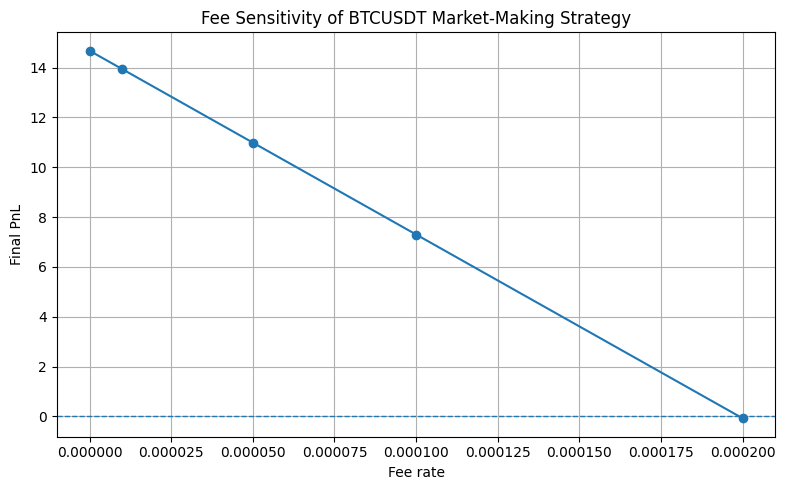

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(fee_sensitivity["fee_rate"], fee_sensitivity["final_pnl"], marker="o")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Fee rate")
plt.ylabel("Final PnL")
plt.title("Fee Sensitivity of BTCUSDT Market-Making Strategy")
plt.grid(True)
plt.tight_layout()

plt.savefig(output_dir / "fee_sensitivity_final_pnl.png", dpi=300)
plt.show()

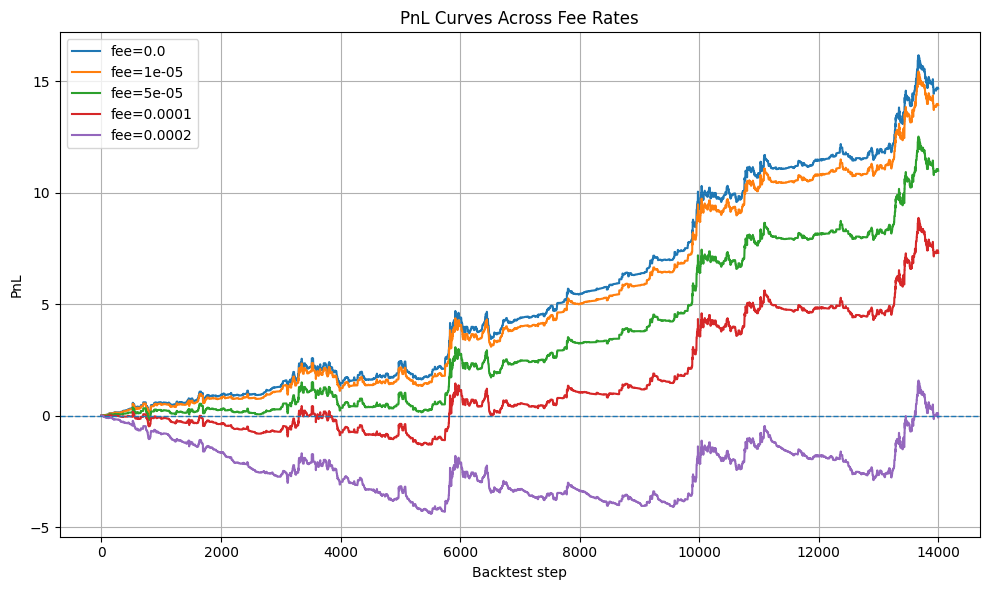

In [18]:
plt.figure(figsize=(10, 6))

for fee_rate, results in all_results.items():
    plt.plot(results["pnl"].values, label=f"fee={fee_rate}")

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Backtest step")
plt.ylabel("PnL")
plt.title("PnL Curves Across Fee Rates")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(output_dir / "all_pnl_curves_by_fee.png", dpi=300)
plt.show()

In [19]:
for fee_rate, results in all_results.items():
    print("=" * 60)
    print(f"fee_rate = {fee_rate}")
    print(results["risk_reason"].value_counts())

fee_rate = 0.0
risk_reason
ask_blocked            3471
volatility_too_high    3435
bid_blocked            3399
ok                     2618
both_sides_blocked      858
depth_too_low           219
terminal_unwind           1
Name: count, dtype: int64
fee_rate = 1e-05
risk_reason
ask_blocked            3471
volatility_too_high    3435
bid_blocked            3399
ok                     2618
both_sides_blocked      858
depth_too_low           219
terminal_unwind           1
Name: count, dtype: int64
fee_rate = 5e-05
risk_reason
ask_blocked            3471
volatility_too_high    3435
bid_blocked            3399
ok                     2618
both_sides_blocked      858
depth_too_low           219
terminal_unwind           1
Name: count, dtype: int64
fee_rate = 0.0001
risk_reason
ask_blocked            3471
volatility_too_high    3435
bid_blocked            3399
ok                     2618
both_sides_blocked      858
depth_too_low           219
terminal_unwind           1
Name: count, dtype: int

In [20]:
for fee_rate, trades in all_trades.items():
    print("=" * 60)
    print(f"fee_rate = {fee_rate}")
    if trades.empty:
        print("No trades")
    else:
        print(trades["side"].value_counts())
        display(trades.tail())

fee_rate = 0.0
side
buy     482
sell    473
Name: count, dtype: int64


,timestamp,side,price,quantity,signed_quantity,fee,p_fill,mid_price,inventory_after,cash_after,is_terminal_unwind
950,2026-04-29 04:29:04.357117+00:00,buy,77021.25,0.001,0.001,0.0,0.078657,77025.645,0.009,-681.37584,False
951,2026-04-29 04:29:08.379637+00:00,buy,77033.08,0.001,0.001,0.0,0.078800,77037.465,0.010,-758.40892,False
952,2026-04-29 04:31:06.059124+00:00,sell,77043.38,0.001,-0.001,0.0,0.078657,77038.985,0.009,-681.36554,False
953,2026-04-29 04:31:24.605634+00:00,buy,77016.35,0.001,0.001,0.0,0.078800,77020.735,0.010,-758.38189,False
954,2026-04-29 04:48:50.088552+00:00,sell,77306.20,0.010,-0.010,0.0,1.000000,77306.205,0.000,14.68011,True


fee_rate = 1e-05
side
buy     482
sell    473
Name: count, dtype: int64


,timestamp,side,price,quantity,signed_quantity,fee,p_fill,mid_price,inventory_after,cash_after,is_terminal_unwind
950,2026-04-29 04:29:04.357117+00:00,buy,77021.25,0.001,0.001,0.000770,0.078657,77025.645,0.009,-682.103647,False
951,2026-04-29 04:29:08.379637+00:00,buy,77033.08,0.001,0.001,0.000770,0.078800,77037.465,0.010,-759.137497,False
952,2026-04-29 04:31:06.059124+00:00,sell,77043.38,0.001,-0.001,0.000770,0.078657,77038.985,0.009,-682.094888,False
953,2026-04-29 04:31:24.605634+00:00,buy,77016.35,0.001,0.001,0.000770,0.078800,77020.735,0.010,-759.112008,False
954,2026-04-29 04:48:50.088552+00:00,sell,77306.20,0.010,-0.010,0.007731,1.000000,77306.205,0.000,13.942261,True


fee_rate = 5e-05
side
buy     482
sell    473
Name: count, dtype: int64


,timestamp,side,price,quantity,signed_quantity,fee,p_fill,mid_price,inventory_after,cash_after,is_terminal_unwind
950,2026-04-29 04:29:04.357117+00:00,buy,77021.25,0.001,0.001,0.003851,0.078657,77025.645,0.009,-685.014875,False
951,2026-04-29 04:29:08.379637+00:00,buy,77033.08,0.001,0.001,0.003852,0.078800,77037.465,0.010,-762.051806,False
952,2026-04-29 04:31:06.059124+00:00,sell,77043.38,0.001,-0.001,0.003852,0.078657,77038.985,0.009,-685.012279,False
953,2026-04-29 04:31:24.605634+00:00,buy,77016.35,0.001,0.001,0.003851,0.078800,77020.735,0.010,-762.032479,False
954,2026-04-29 04:48:50.088552+00:00,sell,77306.20,0.010,-0.010,0.038653,1.000000,77306.205,0.000,10.990867,True


fee_rate = 0.0001
side
buy     482
sell    473
Name: count, dtype: int64


,timestamp,side,price,quantity,signed_quantity,fee,p_fill,mid_price,inventory_after,cash_after,is_terminal_unwind
950,2026-04-29 04:29:04.357117+00:00,buy,77021.25,0.001,0.001,0.007702,0.078657,77025.645,0.009,-688.653910,False
951,2026-04-29 04:29:08.379637+00:00,buy,77033.08,0.001,0.001,0.007703,0.078800,77037.465,0.010,-765.694693,False
952,2026-04-29 04:31:06.059124+00:00,sell,77043.38,0.001,-0.001,0.007704,0.078657,77038.985,0.009,-688.659017,False
953,2026-04-29 04:31:24.605634+00:00,buy,77016.35,0.001,0.001,0.007702,0.078800,77020.735,0.010,-765.683069,False
954,2026-04-29 04:48:50.088552+00:00,sell,77306.20,0.010,-0.010,0.077306,1.000000,77306.205,0.000,7.301625,True


fee_rate = 0.0002
side
buy     482
sell    473
Name: count, dtype: int64


,timestamp,side,price,quantity,signed_quantity,fee,p_fill,mid_price,inventory_after,cash_after,is_terminal_unwind
950,2026-04-29 04:29:04.357117+00:00,buy,77021.25,0.001,0.001,0.015404,0.078657,77025.645,0.009,-695.931979,False
951,2026-04-29 04:29:08.379637+00:00,buy,77033.08,0.001,0.001,0.015407,0.078800,77037.465,0.010,-772.980466,False
952,2026-04-29 04:31:06.059124+00:00,sell,77043.38,0.001,-0.001,0.015409,0.078657,77038.985,0.009,-695.952494,False
953,2026-04-29 04:31:24.605634+00:00,buy,77016.35,0.001,0.001,0.015403,0.078800,77020.735,0.010,-772.984248,False
954,2026-04-29 04:48:50.088552+00:00,sell,77306.20,0.010,-0.010,0.154612,1.000000,77306.205,0.000,-0.076860,True
